### Importing Datasets and libraries

In [1]:
import sklearn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

X_scaled = pd.read_csv(r"C:\Users\Niraj Mhatre\projects\Credit-Behaviour-Segmentation\processed\features_scaled.csv") 
X = pd.read_csv(r"C:\Users\Niraj Mhatre\projects\Credit-Behaviour-Segmentation\processed\features_unscaled.csv")
df_profiling = pd.read_csv(r"C:\Users\Niraj Mhatre\projects\Credit-Behaviour-Segmentation\processed\profiling_features.csv")

add a note on why we resample

In [2]:
sample_size = 20000

sample_idx = X.sample(
    n=sample_size,
    random_state=42
).index

X_sample = X.loc[sample_idx].reset_index(drop=True)
df_sc = X_scaled.loc[sample_idx].reset_index(drop=True)

In [3]:
df_sc.head()

,LogIncome,LogIncomePerHead,LogDebtPayment,Utilisation,DebtToIncome,Age,TotalCreditLines,SecuredShare,LinesPerAdultYear,HouseholdSize
0,0.518697,0.567077,0.509183,0.437613,0.499517,0.572894,0.439391,0.000000,0.405414,0.0
1,0.518697,0.567077,0.509183,0.370951,0.499517,0.578823,0.439391,0.000000,0.403237,0.0
2,0.429968,0.492391,0.540778,0.575492,0.599231,0.597366,0.577647,0.000000,0.500362,0.0
3,0.541289,0.589997,0.530674,0.414599,0.499517,0.516366,0.506399,0.606017,0.484246,0.0
4,0.463900,0.437602,0.453325,0.490787,0.461123,0.706181,0.413495,0.589810,0.354444,0.2


we have already dealt with outliers detection/treatmeant, scaling and the correlation part and we saw the most correlated features also and we observed that in the dataset, many features are correlated and that all our data was numerical so we proceed with pca 

### Dimensionality reduction using PCA

In [4]:
from sklearn.decomposition import PCA
p = PCA( svd_solver="full", whiten=True)
X_pca = p.fit_transform(df_sc)

var_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(p.n_components_)],
    'Variance Ratio': p.explained_variance_ratio_,
    'Cumulative Ratio': np.cumsum(p.explained_variance_ratio_)
})

print("Variance Retained per Component")
print(var_df.round(4))

loadings = pd.DataFrame(
    p.components_, 
    columns=df_sc.columns, 
    index=[f'PC{i+1}' for i in range(p.n_components_)]
)
print("\n Component Loadings (Weights)")
print(loadings.round(3))

Variance Retained per Component
     PC  Variance Ratio  Cumulative Ratio
0   PC1          0.3891            0.3891
1   PC2          0.2103            0.5994
2   PC3          0.1250            0.7244
3   PC4          0.0895            0.8139
4   PC5          0.0848            0.8987
5   PC6          0.0549            0.9536
6   PC7          0.0383            0.9919
7   PC8          0.0035            0.9955
8   PC9          0.0031            0.9985
9  PC10          0.0015            1.0000

 Component Loadings (Weights)
      LogIncome  LogIncomePerHead  LogDebtPayment  Utilisation  DebtToIncome  \
PC1       0.126             0.030           0.277        0.009         0.225   
PC2      -0.044            -0.313          -0.024        0.180         0.004   
PC3      -0.100            -0.018           0.134        0.921         0.222   
PC4      -0.078            -0.049           0.214       -0.218         0.312   
PC5       0.643             0.524           0.145        0.188        -0.34

we look at scree plot and cumulative variance plot now

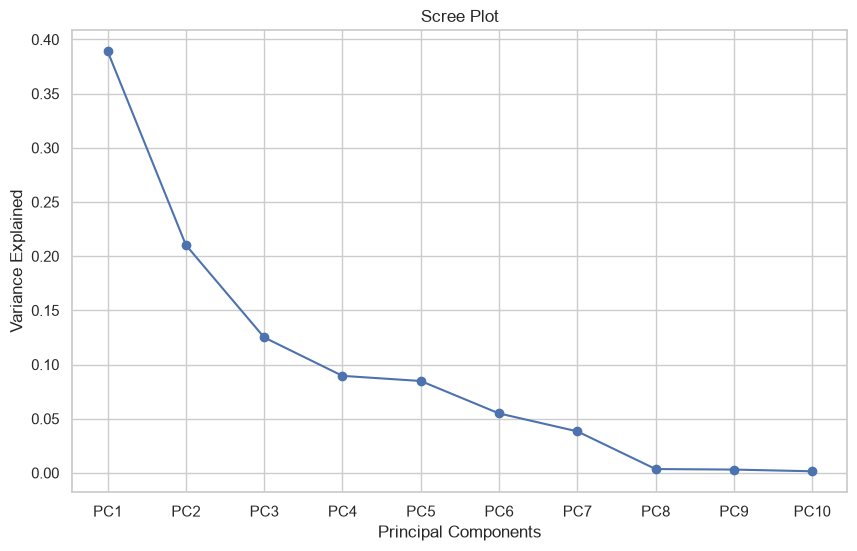

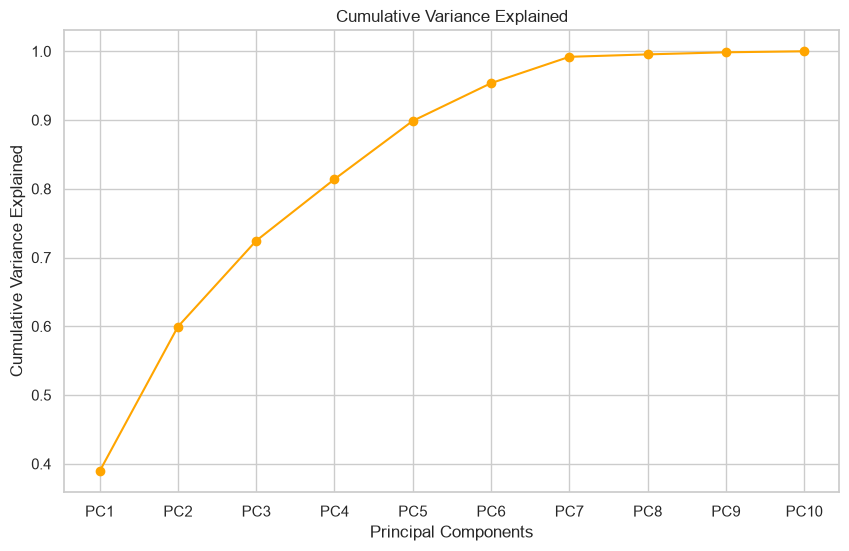

In [5]:
#scree plot
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
plt.plot(var_df['PC'], var_df['Variance Ratio'], marker='o')
plt.title('Scree Plot')
plt.xlabel('Principal Components')
plt.ylabel('Variance Explained')
plt.show()

#cumulative variance plot
plt.figure(figsize=(10, 6))
plt.plot(var_df['PC'], var_df['Cumulative Ratio'], marker='o', color='orange')
plt.title('Cumulative Variance Explained')
plt.xlabel('Principal Components')
plt.ylabel('Cumulative Variance Explained') 
plt.show()

here we observe that 6 variables explain 95% of the information so we choose till PC6 the 6th component

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Transform data to retained components
X_pca = p.transform(df_sc)[:, :6]

cluster_centers = {}
cluster_labels = {}
inertia = {}
silhouette_scores = {}
calinski_harabasz_scores = {}
davies_bouldin_scores = {}

# Fit K-Means and calculate metrics across range of K
for k in range(2, 12):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=96, n_init='auto')
    labels = kmeans.fit_predict(X_pca)
    
    
    cluster_labels[k] = labels
    cluster_centers[k] = kmeans.cluster_centers_
    inertia[k] = kmeans.inertia_
    
    
    silhouette_scores[k] = silhouette_score(X_pca, labels, random_state=96)
    calinski_harabasz_scores[k] = calinski_harabasz_score(X_pca, labels)
    davies_bouldin_scores[k] = davies_bouldin_score(X_pca, labels)

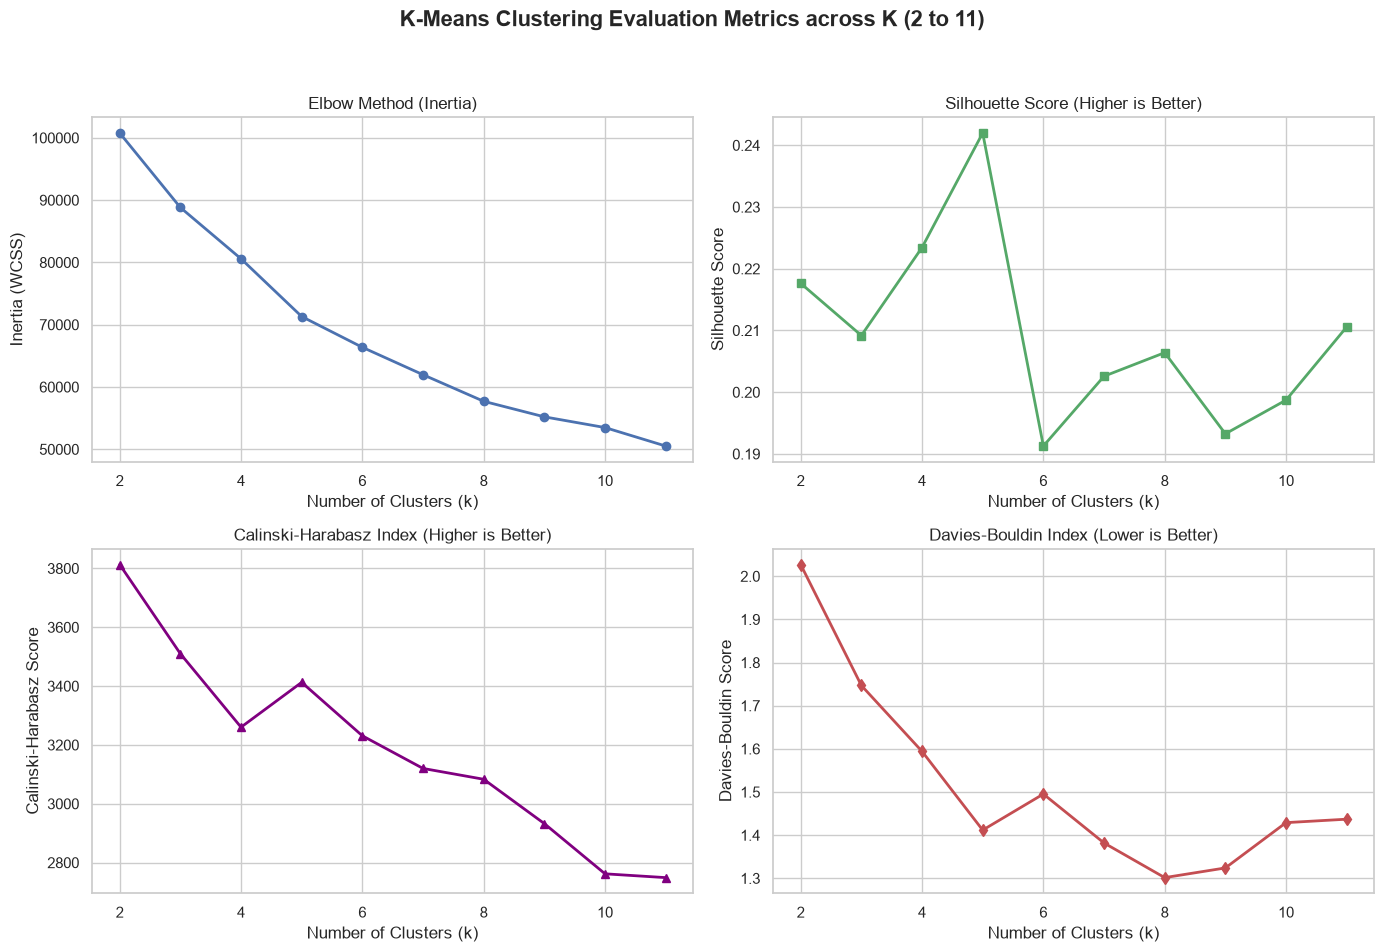

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
k_values = list(range(2, 12))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('K-Means Clustering Evaluation Metrics across K (2 to 11)', fontsize=16, fontweight='bold')

# Inertia (Elbow Method) - Lower is better
axes[0, 0].plot(k_values, [inertia[k] for k in k_values], marker='o', color='b', linewidth=2)
axes[0, 0].set_title('Elbow Method (Inertia)', fontsize=12)
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia (WCSS)')

# Silhouette Score - Higher is better
axes[0, 1].plot(k_values, [silhouette_scores[k] for k in k_values], marker='s', color='g', linewidth=2)
axes[0, 1].set_title('Silhouette Score (Higher is Better)', fontsize=12)
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')

# Calinski-Harabasz Index - Higher is better
axes[1, 0].plot(k_values, [calinski_harabasz_scores[k] for k in k_values], marker='^', color='purple', linewidth=2)
axes[1, 0].set_title('Calinski-Harabasz Index (Higher is Better)', fontsize=12)
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Calinski-Harabasz Score')

# Davies-Bouldin Index - Lower is better
axes[1, 1].plot(k_values, [davies_bouldin_scores[k] for k in k_values], marker='d', color='r', linewidth=2)
axes[1, 1].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=12)
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Davies-Bouldin Score')

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()

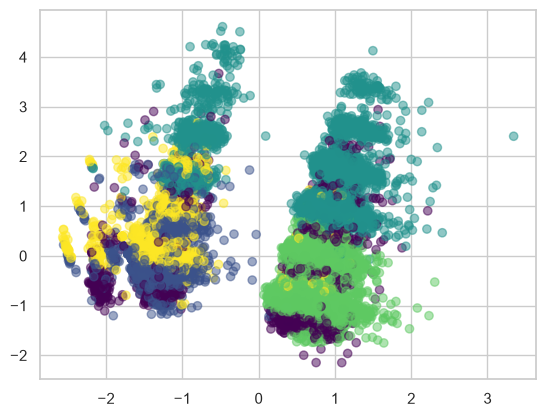

In [8]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels[5], cmap='viridis', alpha=0.5)

### Observations from PCA Visualization

The scatter plot obtained using the first six principal components shows considerable overlap between the clusters obtained by K-Means.

Since PCA projects the data onto a lower-dimensional space, this visualization alone is not sufficient to conclude that K-Means has performed poorly. However, the observed overlap suggests that the underlying cluster structure may not be well represented by convex, spherical clusters, which is an assumption of K-Means.

To investigate whether the data contains clusters of arbitrary shapes or varying densities, we next evaluate DBSCAN, a density-based clustering algorithm that does not require the number of clusters to be specified beforehand and is capable of identifying noise points.

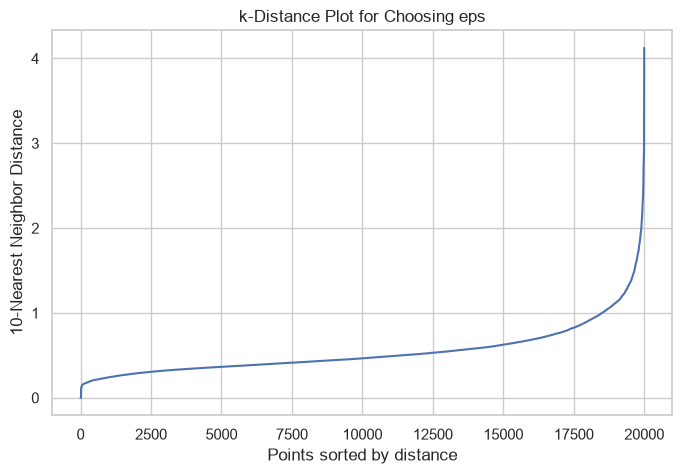

In [10]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

k = 10        # Same as min_samples

neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_pca)

distances, indices = neighbors.kneighbors(X_pca)

distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8,5))

plt.plot(distances)

plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-Nearest Neighbor Distance")
plt.title("k-Distance Plot for Choosing eps")

plt.grid(True)
plt.show()

In [11]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# -----------------------------
# Hyperparameter Grid
# -----------------------------
eps_values = np.arange(0.5, 2.1, 0.2)
min_samples_values = [5, 8, 10, 12, 15, 20]

dbscan_results = []

# -----------------------------
# Hyperparameter Tuning Loop
# -----------------------------
for eps in eps_values:
    for min_samples in min_samples_values:
        
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_pca)

        # Basic Stats
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_percentage = (n_noise / len(labels)) * 100

        # Calculate metrics only if there are valid clusters (> 1) and not 100% noise
        if n_clusters > 1 and n_clusters < len(labels) - n_noise:
            # Mask out noise points (-1) for internal metrics calculation
            non_noise_mask = (labels != -1)
            X_filtered = X_pca[non_noise_mask]
            labels_filtered = labels[non_noise_mask]

            # Use sample_size for fast silhouette estimation
            sil = silhouette_score(X_filtered, labels_filtered, sample_size=10000, random_state=42)
            ch = calinski_harabasz_score(X_filtered, labels_filtered)
            db = davies_bouldin_score(X_filtered, labels_filtered)
        else:
            sil, ch, db = np.nan, np.nan, np.nan

        # Record iteration results
        dbscan_results.append({
            'eps': round(eps, 2),
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_pct': round(noise_percentage, 2),
            'silhouette': round(sil, 4) if not np.isnan(sil) else np.nan,
            'calinski_harabasz': round(ch, 2) if not np.isnan(ch) else np.nan,
            'davies_bouldin': round(db, 4) if not np.isnan(db) else np.nan
        })

# -----------------------------
# Convert to DataFrame & Display
# -----------------------------
results_df = pd.DataFrame(dbscan_results)

# Filter out runs that failed to form proper clusters or resulted in >50% noise
valid_results = results_df[(results_df['n_clusters'] > 1) & (results_df['noise_pct'] < 50)]

print("="*60)
print("TOP CONFIGURATIONS BY SILHOUETTE SCORE")
print("="*60)
print(valid_results.sort_values(by='silhouette', ascending=False).head(10).to_string(index=False))

TOP CONFIGURATIONS BY SILHOUETTE SCORE
 eps  min_samples  n_clusters  n_noise  noise_pct  silhouette  calinski_harabasz  davies_bouldin
 1.9            8           2       41       0.21      0.5351              86.19          0.4713
 1.9           12           2       48       0.24      0.5323              86.32          0.4711
 1.9           10           2       46       0.23      0.5318              86.29          0.4711
 1.9            5           2       37       0.18      0.5315              86.09          0.4715
 1.7           15           2      131       0.66      0.5195             172.89          0.5778
 1.7           12           3      105       0.53      0.5120             148.71          0.5166
 1.7            5           4       57       0.29      0.3990              86.97          0.4835
 1.7           10           5       76       0.38      0.3940             109.17          0.5129
 1.7            8           5       62       0.31      0.3905             113.50        

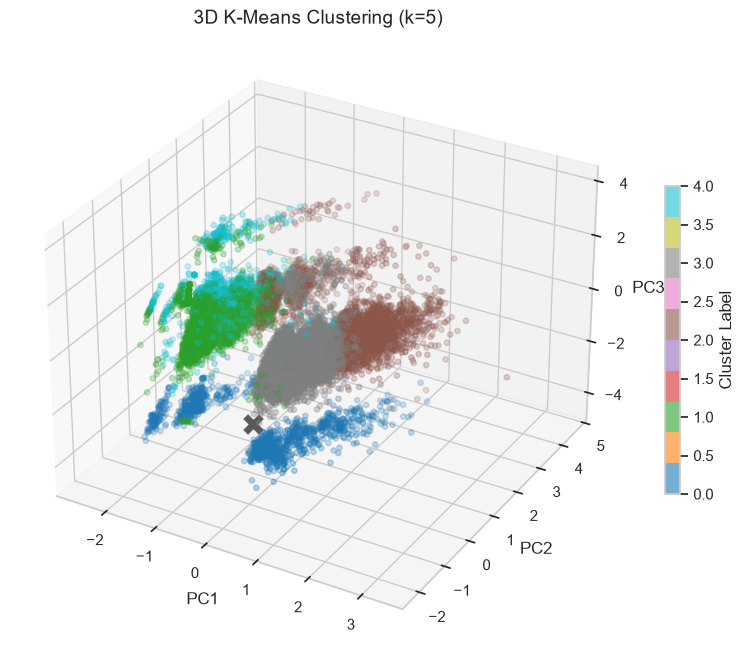

In [12]:
import matplotlib.pyplot as plt

k_choice = 5  # Change to your chosen k
labels = cluster_labels[k_choice]
centers = cluster_centers[k_choice]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for points
scatter = ax.scatter(
    xs=X_pca[:, 0], 
    ys=X_pca[:, 1], 
    zs=X_pca[:, 2], 
    c=labels, 
    cmap='tab10', 
    s=15, 
    alpha=0.6
)

# Plot cluster centroids
ax.scatter(
    centers[:, 0], 
    centers[:, 1], 
    centers[:, 2], 
    c='black', 
    s=250, 
    marker='X', 
    edgecolor='white',
    label='Centroids'
)

ax.set_title(f'3D K-Means Clustering (k={k_choice})', fontsize=14)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
fig.colorbar(scatter, ax=ax, label='Cluster Label', shrink=0.5)
plt.show()

In [13]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd
import numpy as np

# --------------------------
# Hyperparameter
# --------------------------

n_clusters = 5

# --------------------------
# Train Model
# --------------------------

gmm = GaussianMixture(
    n_components=n_clusters,
    covariance_type='full',
    random_state=42
)

gmm_labels = gmm.fit_predict(X_pca)

# --------------------------
# Evaluation
# --------------------------

sil_score = silhouette_score(X_pca, gmm_labels)
db_score = davies_bouldin_score(X_pca, gmm_labels)

print(f"Silhouette Score : {sil_score:.4f}")
print(f"Davies-Bouldin   : {db_score:.4f}")

# --------------------------
# Cluster Sizes
# --------------------------

cluster_summary = pd.Series(gmm_labels).value_counts().sort_index()

print("\nCluster Sizes")
print(cluster_summary)

Silhouette Score : 0.1756
Davies-Bouldin   : 2.0927

Cluster Sizes
0    1493
1    4257
2    2577
3    5709
4    5964
Name: count, dtype: int64


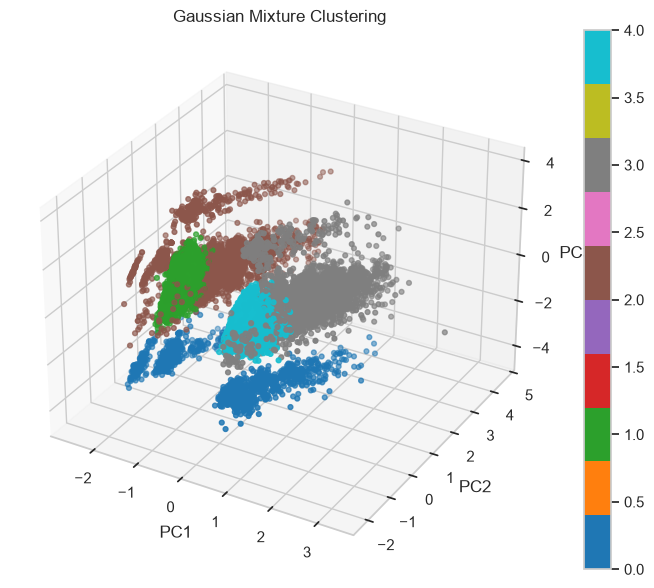

In [14]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9,7))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=gmm_labels,
    cmap='tab10',
    s=12
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("Gaussian Mixture Clustering")

plt.colorbar(scatter)

plt.show()